In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from sklearn.model_selection import train_test_split
from split.create_split import create_split

from models.random_forest import RandomForestPredictor

from main_scorer import mutate_score_sequences, check_already_scored, plot_results, lookup_oracle, plot_umap_embedding
from models.oracle import build_oracle_df, oracle_exists, oracle_lookup
from models.lstm_goaldirected import LSTMGoalDirected

SEED = 42

2026-02-24 15:54:07.240081: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/meier/Desktop/PracticalWork/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Train LSTM with Reniforcement Learning - TFBind8

In [2]:
# Load dataset: TFBIND 8 - SIX6 REF R1
df = pd.read_csv('tf_bind_8-SIX6_REF_R1/dataset.csv')

# Add a column encoded sequence instead of the cols 0-7
df['encoded_sequence'] = df.apply(lambda row: [row[str(i)] for i in range(8)], axis=1)


df['split'] = ['None'] * len(df)

df = create_split(df, k_seeds=50, n_training_seeds=20, random_state=42)

train_df = df[df['split'] == 'train']

x = train_df.iloc[:, :-6].values
print('Shape of x:', x.shape)
print('First row of x:', x[0])
y = train_df['binding_scores'].values

# One-hot encode and reshape to 3D for LSTM (samples, timesteps, features)
x_one_hot = np.array([tf.one_hot(seq, depth=4).numpy() for seq in x])
print('One-hot encoded shape (3D):', x_one_hot.shape)

X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.1, random_state=SEED)

print('Training samples: ', X_train.shape[0])
print('Validation samples: ', X_val.shape[0])
print('Input shape (timesteps, features):', X_train.shape[1:])

Shape of x: (8670, 8)
First row of x: [0 0 0 0 0 0 2 1]


I0000 00:00:1771944876.989590  820553 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 725 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


One-hot encoded shape (3D): (8670, 8, 4)
Training samples:  7803
Validation samples:  867
Input shape (timesteps, features): (8,)


In [3]:
# check sizes of testsplits
df['split'].value_counts()

split
test_c    38796
test_a    10614
train      8670
test_b     7712
Name: count, dtype: int64

In [4]:

rf = RandomForestPredictor()
rf.train(X_train, y_train)
rf.evaluate(X_val, y_val)

Training Random Forest model...
Training completed.
R2 Score: 0.1591813442313632
MSE: 0.004913540435817987
Spearman Correlation: 0.3804144933321289


{'r2': 0.1591813442313632,
 'mse': 0.004913540435817987,
 'spearman_correlation': np.float64(0.3804144933321289)}

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset

X_train_tensor = torch.LongTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [6]:
def train_goal_directed_model(model, loader, epochs=20, lr= 0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()

    model.train()

    for epoch in range(epochs):
        epoch_loss = 0
        for batch_x, batch_y in loader:
            optimizer.zero_grad()

            input = batch_x[:, :-1]
            target_part = batch_x[:, 1:]
            #print('Input shape:', input.shape)
            #print('Target part shape:', batch_y.shape)
            logits, _ = model(input, batch_y)
            loss = criterion(logits.reshape(-1, 4), target_part.reshape(-1))

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
        if epoch % 5 == 0:
            print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(loader)}')

#### Iterative Feedback Loop with retraining

In [7]:
def rl_loop(model, scorer, num_iterations=6, batch_size = 128):
    values = {'mutation': [], 'predicted_score': []}
    for i in range(num_iterations):
        print(f'-------- Iteration {i+1}/{num_iterations} --------')
        
        new_sequences = []
        # Propose new sequences
        for _ in range(batch_size):
            seq = model.generate(goal_score=1.1, temp = 0.8)
            new_sequences.append(seq)

        new_sequences_np = np.array(new_sequences)
        scores = []

        for seq in new_sequences_np:
            scores.append(scorer.predict(seq))

        scores = np.array(scores)

        normalized_scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)

        threshold = np.percentile(normalized_scores, 80)

        top_sequences = new_sequences_np[normalized_scores >= threshold]
        top_scores = normalized_scores[normalized_scores >= threshold]

        print(f'Average score of proposed: {np.mean(scores):.4f}, Average score of top 20%: {np.mean(top_scores):.4f}')

        # Append for plotting
        top_sequences_one_hot = [tf.one_hot(seq, depth=4).numpy().flatten() for seq in top_sequences]
        values['mutation'].extend(top_sequences) # Store the actual sequences for later analysis
        values['predicted_score'].extend(top_scores)

        # Update model with top sequences
        x_train = torch.LongTensor(top_sequences)
        y_train = torch.FloatTensor(top_scores).view(-1, 1)

        dataloader = DataLoader(TensorDataset(x_train, y_train), batch_size=16, shuffle=True)
        train_goal_directed_model(model, dataloader, epochs=20, lr=0.001)

    return values

model = LSTMGoalDirected(vocab_size=4, embedding_dim=16, seq_len=8, hidden_dim=64)
values = rl_loop(model, rf, num_iterations=6, batch_size=128)
values_df = pd.DataFrame(values)
values_df.head()


-------- Iteration 1/6 --------
Average score of proposed: 0.3381, Average score of top 20%: 0.9144
Epoch 1/20, Loss: 1.3669249415397644
Epoch 6/20, Loss: 1.3297752141952515
Epoch 11/20, Loss: 1.302771270275116
Epoch 16/20, Loss: 1.2889687418937683
-------- Iteration 2/6 --------
Average score of proposed: 0.3495, Average score of top 20%: 0.8623
Epoch 1/20, Loss: 1.1576910018920898
Epoch 6/20, Loss: 1.0872721076011658
Epoch 11/20, Loss: 1.0785107910633087
Epoch 16/20, Loss: 1.024904191493988
-------- Iteration 3/6 --------
Average score of proposed: 0.3609, Average score of top 20%: 0.7454
Epoch 1/20, Loss: 0.7613880634307861
Epoch 6/20, Loss: 0.6891722083091736
Epoch 11/20, Loss: 0.6729491055011749
Epoch 16/20, Loss: 0.6660173237323761
-------- Iteration 4/6 --------
Average score of proposed: 0.3693, Average score of top 20%: 0.6814
Epoch 1/20, Loss: 0.37381898363431293
Epoch 6/20, Loss: 0.30885933339595795
Epoch 11/20, Loss: 0.26994816958904266
Epoch 16/20, Loss: 0.2559972504774729

,mutation,predicted_score
0,"[3, 1, 0, 2, 3, 1, 2, 1]",0.873182
1,"[2, 3, 3, 0, 3, 0, 1, 3]",0.892397
2,"[0, 3, 1, 3, 0, 2, 2, 2]",0.879387
3,"[0, 0, 1, 0, 3, 0, 0, 3]",0.892842
4,"[3, 3, 3, 0, 3, 1, 2, 2]",0.849689


Spearman Correlation: -0.0010


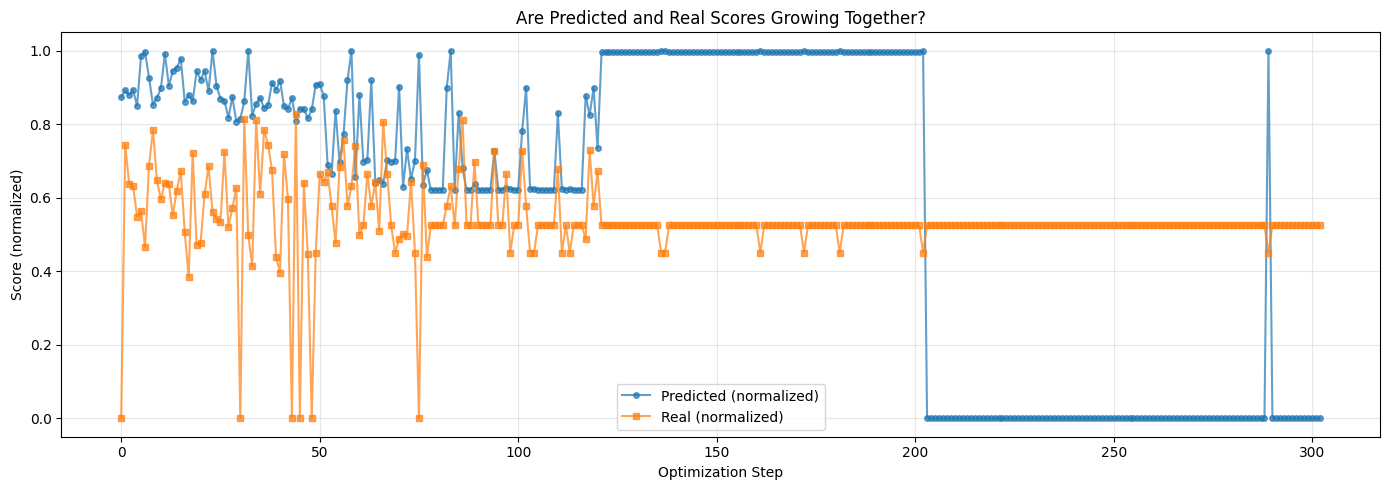

In [8]:
# build a oracle with test sets a, b, c 
oracle = build_oracle_df(df[df['split'].isin(['test_a', 'test_b', 'test_c'])])
df_values = lookup_oracle(values_df, oracle)

plot_results(df_values)

In [9]:
from models.oracle import oracle_lookup

def lookup_oracle_testset(values, oracle):
    """ Look up real scores in generated sequences. If not found, drop the row. """
    drop_cont = 0
    scores = []
    for seq in values['mutation']:
        score = oracle_lookup(oracle, seq)
        if score is not None and score > 0.0:
            scores.append(score)
        else:
            scores.append(np.nan)
            drop_cont += 1
    print(f'Number of sequences not found in oracle: {drop_cont}')
    values['real_score'] = scores
    return values


Number of sequences not found in oracle: 75
Spearman Correlation: 0.0610


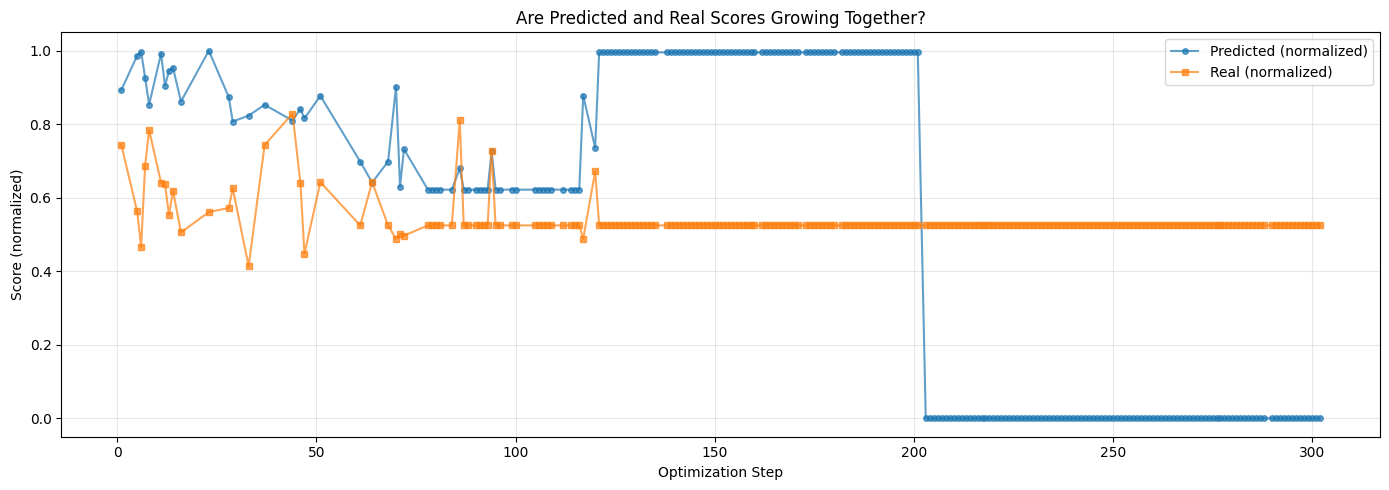

In [10]:
values_copy = values_df.copy()
test_a_oracle = build_oracle_df(df[df['split'] == 'test_a'])
test_a_df = lookup_oracle_testset(values_copy, test_a_oracle)
# drop rows with NaN real_score (sequences not found in oracle)
test_a_df = test_a_df.dropna(subset=['real_score'], inplace=False)
plot_results(test_a_df)

In [ ]:
test_a_df['mutation'] = test_a_df['mutation'].apply(
    lambda seq: tf.one_hot(list(seq), depth=20).numpy().flatten()
)

plot_umap_embedding(df, 'test_a', test_a_df)

Number of sequences not found in oracle: 163
Spearman Correlation: nan


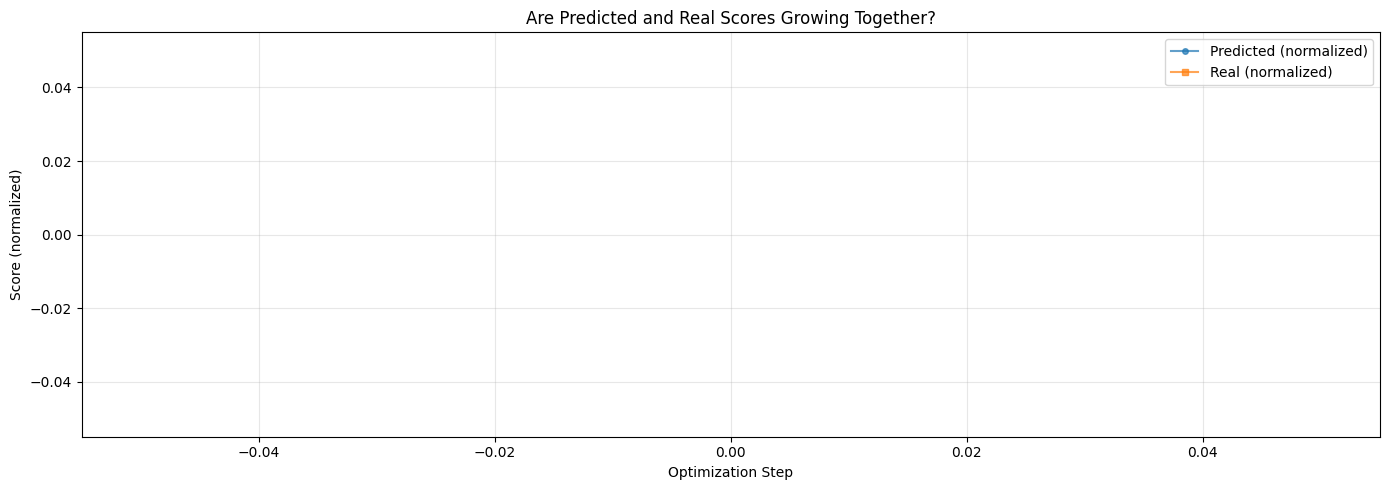

In [21]:
values_copy = values_df.copy()
test_b_oracle = build_oracle_df(df[df['split'] == 'test_b'])

test_b_df = lookup_oracle_testset(values_copy, test_b_oracle)
# drop rows with NaN real_score (sequences not found in oracle)
test_b_df = test_b_df.dropna(subset=['real_score'], inplace=False)
plot_results(test_b_df)

Number of sequences not found in oracle: 163
Spearman Correlation: nan


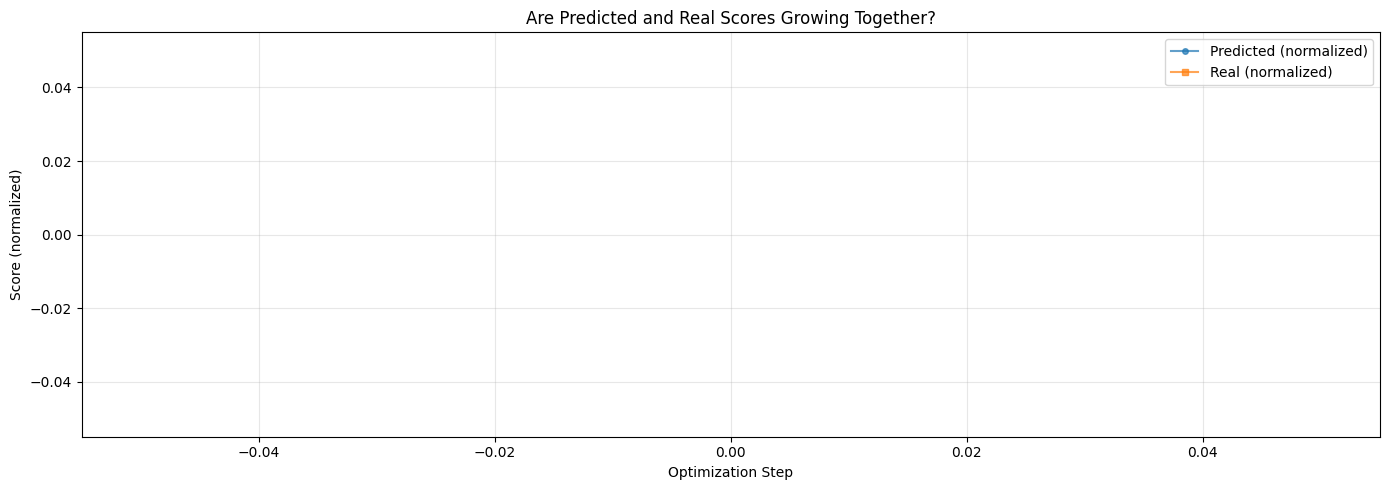

In [23]:
values_copy = values_df.copy()
test_c_oracle = build_oracle_df(df[df['split'] == 'test_c'])
test_c_df = lookup_oracle_testset(values_copy, test_c_oracle)
test_c_df = test_c_df.dropna(subset=['real_score'], inplace=False)
plot_results(test_c_df)

In [ ]:
# Plot all three test_df together into a UMap to see trajecoties
from matplotlib.patches import FancyArrowPatch
import umap
from sklearn.preprocessing import StandardScaler

X_oracle_onehot = np.vstack(oracle['one_hot_seq'].values)

X_trajectory_a = np.vstack(test_a_df['mutation'].values)
X_trajectory_b = np.vstack(test_b_df['mutation'].values)
X_trajectory_c = np.vstack(test_c_df['mutation'].values)

X_combined = np.vstack([X_oracle_onehot, X_trajectory_a, X_trajectory_b, X_trajectory_c])

reducer = umap.UMAP(n_components=4, random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_combined)

# split embedding back into oracle and trajectoies a, b, c
oracle_embedded = embedding[:len(oracle)]
a_embedded = embedding[len(oracle):len(oracle)+len(test_a_df)]
b_embedded = embedding[len(oracle)+len(test_a_df):len(oracle)+len(test_a_df)+len(test_b_df)]
c_embedded = embedding[len(oracle)+len(test_a_df)+len(test_b_df):]

oracle_scores = oracle['binding_scores'].values
a_scores = test_a_df['real_score'].values
b_scores = test_b_df['real_score'].values
c_scores = test_c_df['real_score'].values

fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(
    oracle_embedded[:, 0], 
    oracle_embedded[:, 1], 
    c=oracle_scores, 
    cmap='viridis', 
    alpha=0.6, 
)

plt.colorbar(scatter, label='Binding Score')

for i in range(len(a_embedded)-1):
    ax.add_patch(FancyArrowPatch(a_embedded[i], a_embedded[i+1], color='red', arrowstyle='->', mutation_scale=10, alpha=0.7))

for i in range(len(b_embedded)-1):
    ax.add_patch(FancyArrowPatch(b_embedded[i], b_embedded[i+1], color='blue', arrowstyle='->', mutation_scale=10, alpha=0.7))

for i in range(len(c_embedded)-1):
    ax.add_patch(FancyArrowPatch(c_embedded[i], c_embedded[i+1], color='green', arrowstyle='->', mutation_scale=10, alpha=0.7))




ax.set_title('UMAP Projection of Oracle and RL Trajectories')
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.legend(['Oracle', 'Trajectory A', 'Trajectory B', 'Trajectory C'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

